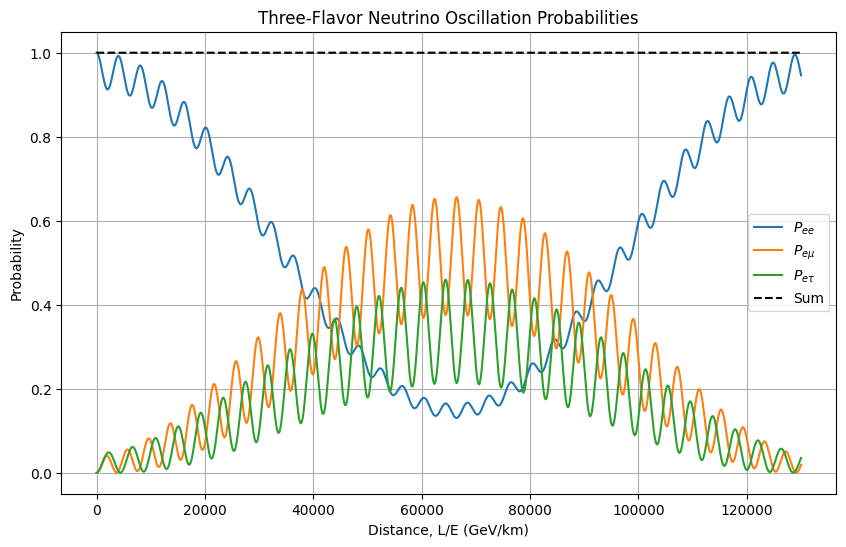

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Mixing angles in degrees
theta12 = 33.48
theta13 = 8.50
theta23 = 42.3
delta_CP = 0  # CP phase (set to 0 for no CP violation)

# Convert angles to radians
theta12 = np.deg2rad(theta12)
theta13 = np.deg2rad(theta13)
theta23 = np.deg2rad(theta23)
delta_CP = np.deg2rad(delta_CP)

# Mass squared differences in eV^2
delta_m21_sq = 7.5e-5
delta_m31_sq = 2.457e-3
delta_m32_sq = 2.382e-3

# Construct the PMNS matrix
def pmns_matrix(t12, t13, t23, d_cp):
    # Rotation matrices
    U12 = np.array([[np.cos(t12), np.sin(t12), 0],
                    [-np.sin(t12), np.cos(t12), 0],
                    [0, 0, 1]], dtype=complex)
    U13 = np.array([[np.cos(t13), 0, np.sin(t13)*np.exp(-1j*d_cp)],
                    [0, 1, 0],
                    [-np.sin(t13)*np.exp(1j*d_cp), 0, np.cos(t13)]], dtype=complex)
    U23 = np.array([[1, 0, 0],
                    [0, np.cos(t23), np.sin(t23)],
                    [0, -np.sin(t23), np.cos(t23)]], dtype=complex)
    # PMNS matrix
    U = U23 @ U13 @ U12
    return U

U = pmns_matrix(theta12, theta13, theta23, delta_CP)

# Energy (GeV) and distance array (km)
E = 1  # Neutrino energy
L = np.linspace(0, 130000, 5000)  # Distance range

# Oscillation parameters
delta21 = (1.27 * delta_m21_sq * L) / (4 * E)
delta31 = (1.27 * delta_m31_sq * L) / (4 * E)
delta32 = (1.27 * delta_m32_sq * L) / (4 * E)

# Precompute sine terms
sin21 = np.sin(delta21)**2
sin31 = np.sin(delta31)**2
sin32 = np.sin(delta32)**2
sin2_21 = np.sin(2 * delta21)
sin2_31 = np.sin(2 * delta31)
sin2_32 = np.sin(2 * delta32)


# Survival probability Pee
abs_U_e = np.abs(U[0, :])**2  # |U_ei|^2
term_21_ee = abs_U_e[0] * abs_U_e[1]
term_31_ee = abs_U_e[0] * abs_U_e[2]
term_32_ee = abs_U_e[1] * abs_U_e[2]
P_ee = 1 - 4 * (term_21_ee * sin21 + term_31_ee * sin31 + term_32_ee * sin32)

# Transition probability Pemu
def transition_prob(alpha, beta, U, sin_terms, sin2_terms):
    pairs = [(0,1), (0,2), (1,2)]
    sum_real, sum_imag = 0, 0
    for idx, (i,j) in enumerate(pairs):
        term = U[alpha, i] * np.conj(U[beta, i]) * np.conj(U[alpha, j]) * U[beta, j]
        delta_sin = [sin21, sin31, sin32][idx]
        delta_sin2 = [sin2_21, sin2_31, sin2_32][idx]
        sum_real += np.real(term) * delta_sin
        sum_imag += np.imag(term) * delta_sin2
    return -4 * sum_real + 2 * sum_imag

P_emu = transition_prob(0, 1, U, [sin21, sin31, sin32], [sin2_21, sin2_31, sin2_32])
P_etau = transition_prob(0, 2, U, [sin21, sin31, sin32], [sin2_21, sin2_31, sin2_32])

# Total probability (should sum to 1)
sum_P = P_ee + P_emu + P_etau

# Plot
plt.figure(figsize=(10, 6))
plt.plot(L, P_ee, label='$P_{ee}$')
plt.plot(L, P_emu, label='$P_{e\mu}$')
plt.plot(L, P_etau, label='$P_{e\\tau}$')
plt.plot(L, sum_P, 'k--', label='Sum')
plt.xlabel('Distance, L/E (GeV/km)')
plt.ylabel('Probability')
plt.title('Three-Flavor Neutrino Oscillation Probabilities')
plt.legend()
plt.grid(True)
plt.show()

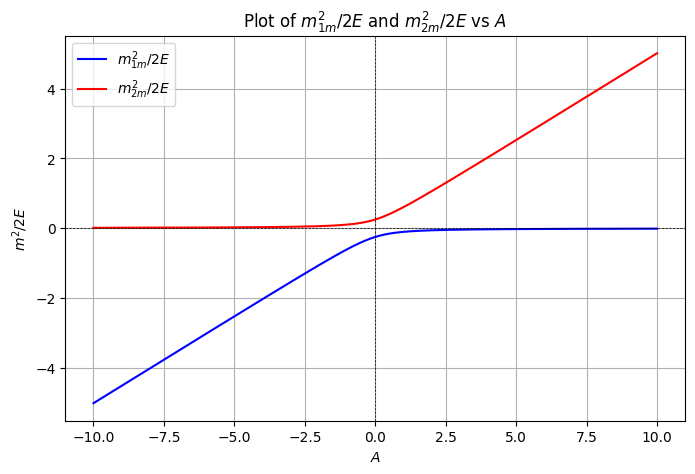

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Define parameters
Delta_m2 = 1 # Arbitrary mass-squared difference
theta = np.pi/4 # Arbitrary mixing angle
E = 1.0  # Arbitrary energy

# Define A range
A_values = np.linspace(-10, 10, 400)

# Compute the terms inside the square root
term1 = (Delta_m2 * np.cos(2 * theta) - A_values) ** 2
term2 = (Delta_m2 * np.sin(2 * theta)) ** 2
sqrt_term = np.sqrt(term1 + term2)

# Compute m1m^2 / 2E and m2m^2 / 2E
m1m_sq_2E = (1 / (2 * E)) * (A_values / 2 - 0.5 * sqrt_term)
m2m_sq_2E = (1 / (2 * E)) * (A_values / 2 + 0.5 * sqrt_term)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(A_values, m1m_sq_2E, label=r'$m_{1m}^2 / 2E$', color='b')
plt.plot(A_values, m2m_sq_2E, label=r'$m_{2m}^2 / 2E$', color='r')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.axvline(0, color='black', linewidth=0.5, linestyle='--')

# Labels and legend
plt.xlabel(r'$A$')
plt.ylabel(r'$m^2 / 2E$')
plt.title(r'Plot of $m_{1m}^2 / 2E$ and $m_{2m}^2 / 2E$ vs $A$')
plt.legend()
plt.grid(True)
plt.show()


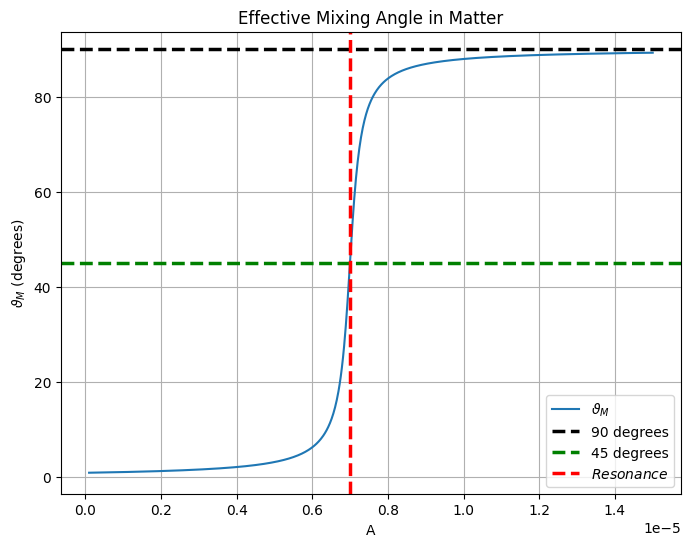

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
Delta_m2 = 7e-6  # eV^2
sin2_2theta = 1e-3
theta = np.arcsin(np.sqrt(sin2_2theta)) / 2  # Calculate theta from sin^2(2theta)


# Calculate A
A = np.linspace(0.01,1.5,1000)*1e-5

# Calculate tan(2*theta_M)
tan_2theta_M = (Delta_m2 * np.sin(2 * theta)) / (Delta_m2 * np.cos(2 * theta) - A)
sin_2theta_M = np.sqrt(1/(1+1/tan_2theta_M**2))
# Calculate theta_M
theta_M = 0.5 * np.arcsin((sin_2theta_M))
for i in range(len(theta_M)):
  if A[i] > Delta_m2 * np.cos(2 * theta):
    theta_M[i] = np.pi/2 - theta_M[i]
# Plotting
plt.figure(figsize=(8, 6))
plt.plot(A, np.degrees(theta_M), label=r'$\vartheta_M$')
plt.xlabel(r'A')
plt.ylabel(r'$\vartheta_M$ (degrees)')
plt.axhline(90, color='black', linewidth=2.5, linestyle='--', label='90 degrees')
plt.axhline(45, color='green', linewidth=2.5, linestyle='--', label='45 degrees')
plt.axvline(Delta_m2* np.cos(2 * theta), color='red', linewidth=2.5, linestyle='--', label=r'$Resonance$')
plt.title('Effective Mixing Angle in Matter')
plt.legend()
plt.grid(True)
plt.show()

In [36]:
import numpy as np
import time
from scipy import interpolate, integrate
import pandas as pd
import matplotlib.pyplot as plt

# Constants
GF = 1.16e-5
MW = 80.385
MZ = 91.1876
mu = 1e-3  # (1 MeV)/(T in MeV)
Mpl = 1.2e19
pi = np.pi

# Decay rate Γa(x, z)
def Gamma_a(x, z):
    return (GF**2 * x * mu**5) / z**5

# Thermal potential VT(x, z)
def VT(x, z):
    return -((14 * np.sqrt(2) * pi**2 * GF * x * mu**5) / (45 * z**5)) * (1 / MZ**2 + 2 / MW**2)

# Δ(x, z, ms)
def Delta(x, z, ms):
    return (ms**2 * z) / (2 * x * mu)

# Fermi-Dirac distribution fva(x)
def fva(x):
    return 2 / (np.exp(x) + 1)

# Import data from files
tgH = pd.read_csv("GstarH.txt", delim_whitespace=True, header=None).values
fgH_interp = interpolate.interp1d(tgH[:, 0], tgH[:, 1], kind='linear', fill_value='extrapolate')

tgS = pd.read_csv("GstarS.txt", delim_whitespace=True, header=None).values
fgS_interp = interpolate.interp1d(tgS[:, 0], tgS[:, 1], kind='linear', fill_value='extrapolate')

# gS evaluated at μ/z
def fgS2(z):
    return fgS_interp(mu / z)

# Hubble parameter
def H(T):
    return 1.66 * np.sqrt(fgH_interp(T)) * T**2 / Mpl

def Hubble(z):
    return H(mu / z)

# Y_nu_s integral
def Ynus(ms, theta):
    def integrand(x, z):
        gamma = Gamma_a(x, z)
        delta = Delta(x, z, ms)
        numerator = delta**2 * np.sin(2 * theta)**2
        denominator = numerator + (gamma / 2)**2 + (delta * np.cos(2 * theta) - VT(x, z))**2
        prefactor = 45 / (2 * pi**2 * fgS2(z)) * (1 / z)
        spectrum = x**2 / (2 * pi**2) * fva(x)
        return prefactor * gamma / (4 * Hubble(z)) * (numerator / denominator) * spectrum

    result, _ = integrate.nquad(integrand, [[0, 10], [1e-5, 10]], opts={'epsrel': 1e-3, 'epsabs': 1e-3})
    return result

# Omega_nu_sh2
def Omega_nu_sh2(ms, theta):
    Y = Ynus(ms, theta)
    return (Y * 2891.2 * ms) / (1.05e-5)
print(Omega_nu_sh2(7.1e-6,5e-5))

0.1793836063248087


/var/folders/_n/200kljtd2dg7jx4fc971742w0000gn/T/ipykernel_32181/2882157382.py:32: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  tgH = pd.read_csv("GstarH.txt", delim_whitespace=True, header=None).values
/var/folders/_n/200kljtd2dg7jx4fc971742w0000gn/T/ipykernel_32181/2882157382.py:35: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  tgS = pd.read_csv("GstarS.txt", delim_whitespace=True, header=None).values


9


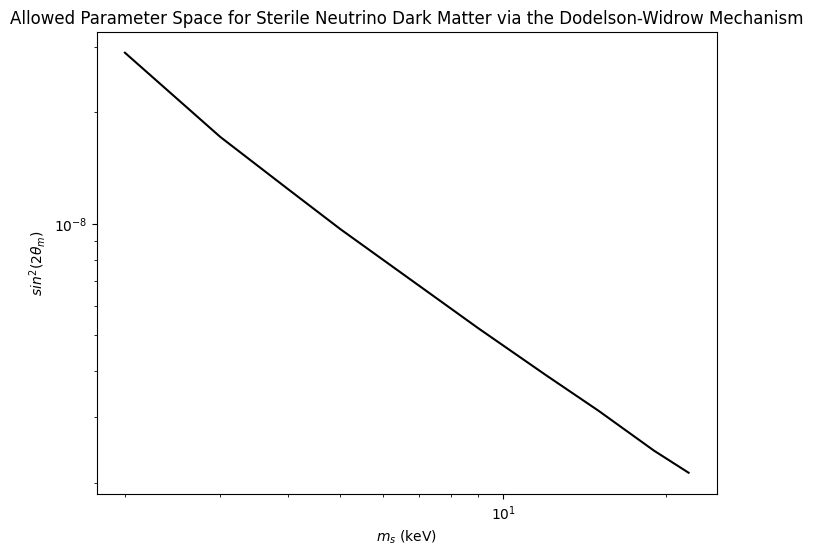

In [37]:
epsilon = 0.001 # adjust as needed
target_value = 0.12

# Define grid ranges for ms and theta (adjust start, stop, and step as needed)
ms_values = np.linspace(1e-6, 5e-5, 50)
theta_values = np.linspace(1*1e-5,9*1e-5, 50)  

# List to store the accepted points (ms, theta, Omega_nu_sh2)
accepted_points = []
i = 1
# Loop over the grid
for ms in ms_values:
    for theta in theta_values:
        try:
            start_time = time.time()
            i += 1
            omega_value = Omega_nu_sh2(ms, theta)
            elapsed = time.time() - start_time
            # print(i,ms,theta,omega_value)
            
            # Check if the computed value is within the tolerance range
            if (target_value - epsilon) <= omega_value <= (target_value + epsilon):
                accepted_points.append((ms, theta, omega_value))
                
        except Exception as e:
            print(f"Error for ms={ms}, theta={theta}: {e}")
print(len(accepted_points))
if accepted_points:
    ms_plot = np.array([p[0] for p in accepted_points])*1000000
    theta_plot = [p[1] for p in accepted_points]
    sin_plot = np.sin(2*np.array(theta_plot))**2
    plt.figure(figsize=(8, 6))
    plt.plot(ms_plot, sin_plot, color='black')
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel(r'$m_s$ (keV)')
    plt.ylabel(r'$sin^2(2\theta_m$)')
    plt.title("Allowed Parameter Space for Sterile Neutrino Dark Matter via the Dodelson-Widrow Mechanism")
    plt.show()